# Bike Sharing User Behavior Analysis

## Objective

This project investigates behavioral differences between registered and casual users in a bike-sharing system.

The main hypothesis is that registered users primarily use the service for commuting purposes, while casual users are more likely to use it for leisure and occasional trips.

The analysis aims to uncover temporal usage patterns and identify factors influencing the behavior of both user groups.

In [2]:
import pandas as pd

hour = pd.read_csv(r"data/hour.csv")


# 1. Data Understanding

Before performing any behavioral analysis, it is important to understand the structure and quality of the dataset. The dataset contains hourly bike rental records along with weather, calendar, and user-related information.

### Dataset Preview

The first few records are displayed below to gain an initial understanding of the available features.

In [3]:
hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Dataset Dimensions

The dataset dimensions indicate the number of observations and available features.

In [36]:

hour.shape

(17379, 17)

### Available Features

The following columns are available for analysis.

In [5]:
hour.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

### Data Types and Missing Values

This step is used to inspect data types and verify whether missing values exist.

In [6]:
hour["dteday"] = pd.to_datetime(hour["dteday"])
hour.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

In [7]:
hour.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

No missing values were detected in the dataset.

### Duplicate Records

Duplicate observations can bias the analysis and should be identified before proceeding.

In [37]:
hour.duplicated().sum()

np.int64(0)

No duplicate records were detected.

### Validating Hour Values

The hour feature should only contain values between 0 and 23.

In [9]:
print((hour["hr"] < 0).sum())
print((hour["hr"] > 23).sum())

0
0


No invalid hour values were found.

In [10]:
hour["cnt"].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

The summary statistics provide an overview of bike rental demand distribution.

# 2. Exploratory Data Analysis

## 2.1 Hourly Usage Patterns

The first question is whether registered and casual users exhibit different usage patterns throughout the day.

A commuting-oriented behavior would likely produce peaks during morning and evening hours, while leisure-oriented behavior may show a different pattern.

To investigate whether registered and casual users exhibit different daily routines, we compare their average usage across the hours of the day.

A commuting-oriented behavior is expected to produce peaks during morning and evening hours.

In [11]:
registered_by_hour = (
    hour.groupby("hr")["registered"]
    .mean()
)

casual_by_hour = (
    hour.groupby("hr")["casual"]
    .mean()
)

registered_by_hour

hr
0      43.739669
1      26.871547
2      18.097902
3       9.011478
4       5.098996
5      18.478382
6      71.882759
7     201.009629
8     337.331499
9     188.418157
10    127.191197
11    148.602476
12    185.021978
13    181.352538
14    165.381344
15    176.327846
16    238.238356
17    387.178082
18    364.390110
19    262.752747
20    189.796703
21    144.059066
22    109.082418
23     72.631868
Name: registered, dtype: float64

In [12]:
casual_by_hour

hr
0     10.158402
1      6.504144
2      4.772028
3      2.715925
4      1.253945
5      1.411437
6      4.161379
7     11.055021
8     21.679505
9     30.891334
10    46.477304
11    59.540578
12    68.293956
13    72.308642
14    75.567901
15    74.905350
16    73.745205
17    74.273973
18    61.120879
19    48.770604
20    36.233516
21    28.255495
22    22.252747
23    15.199176
Name: casual, dtype: float64

The hourly profiles reveal clear behavioral differences between the two user groups.

Registered users exhibit two pronounced peaks during morning and evening hours, consistent with commuting activity.

In contrast, casual users show increased activity during the afternoon, suggesting a greater association with leisure or occasional trips.

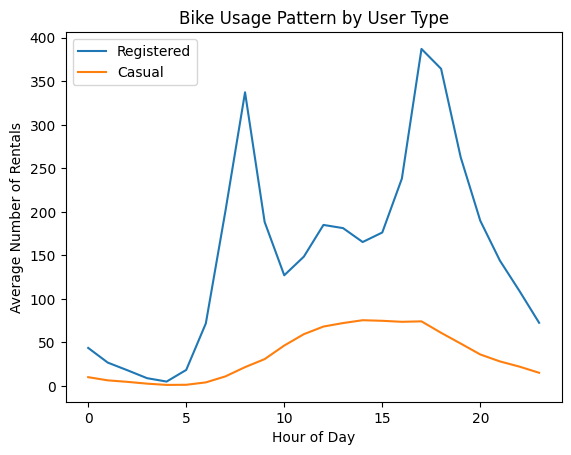

In [13]:
import matplotlib.pyplot as plt

registered_by_hour.plot(label="Registered")
casual_by_hour.plot(label="Casual")

plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Rentals")
plt.title("Bike Usage Pattern by User Type")
plt.legend()
plt.show()

## 2.2 Working Day vs Non-Working Day Analysis

If registered users primarily rely on the bike-sharing system for commuting, their usage should be higher on working days.

Casual users, on the other hand, may be more active during weekends and non-working days.

In [14]:
hour.groupby("workingday")[["registered","casual"]].mean()

,registered,casual
workingday,,
0,123.963910,57.441422
1,167.646439,25.561315


The results support the commuting hypothesis.

Registered users show substantially higher activity on working days, whereas casual users are significantly more active on non-working days.

This finding reinforces the interpretation that registered users mainly rely on the service for routine transportation, while casual users are more likely to use it for leisure purposes.

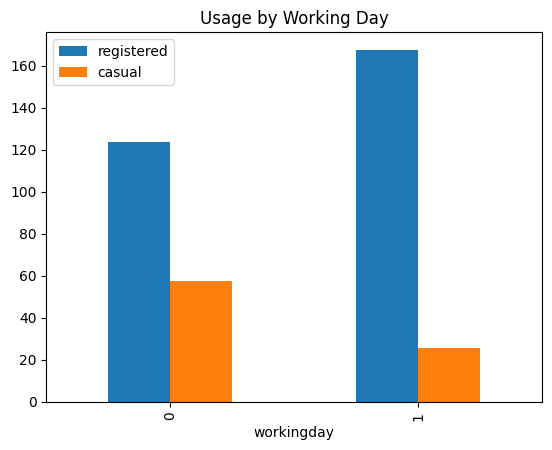

In [15]:
hour.groupby("workingday")[["registered","casual"]].mean().plot(kind="bar")
plt.title("Usage by Working Day")
plt.show()

## 2.3 Weather Impact on User Types

Weather conditions may affect user groups differently.

Casual users are expected to be more sensitive to unfavorable weather because their trips are often optional and leisure-oriented.

Registered users may be less affected due to routine commuting needs.

### Weather Condition Distribution

Before analyzing the impact of weather, it is useful to examine how observations are distributed across different weather categories.

In [16]:
hour["weathersit"].value_counts().sort_index()

weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

This overview helps assess whether all weather categories are sufficiently represented in the dataset.

### Weather Sensitivity Analysis

To examine whether weather conditions affect the two user groups differently, we compare the average number of rentals across weather categories.

In [17]:
hour.groupby("weathersit")[["casual", "registered"]].mean()

,casual,registered
weathersit,,
1,40.545431,164.323841
2,29.595290,145.570202
3,16.055673,95.523608
4,2.666667,71.666667


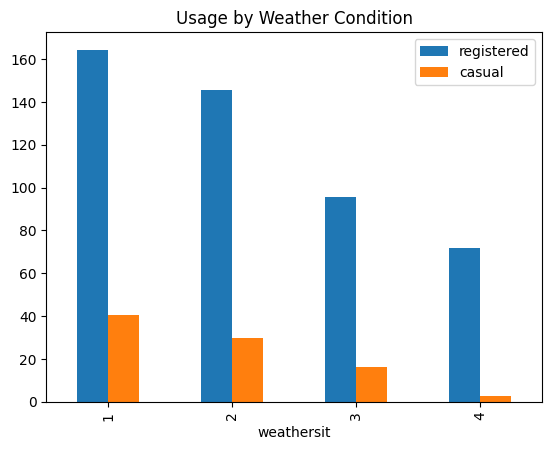

In [18]:
hour.groupby("weathersit")[["registered","casual"]].mean().plot(kind="bar")
plt.title("Usage by Weather Condition")
plt.show()

Casual users appear to be more sensitive to adverse weather conditions than registered users.

## 2.4 Key Findings

- Registered users show a strong bimodal pattern with peaks in the morning and evening, indicating commuting behavior.
- Casual users are more active during midday and weekends, suggesting leisure-oriented usage.
- Registered users are significantly more active on working days, while casual users dominate non-working days.
- Weather conditions affect both groups, but casual users are more sensitive to adverse weather.

# 3. Machine Learning — Bike Demand Prediction

## 3.1 Problem Definition

The goal is to predict the total number of bike rentals (cnt) based on temporal and environmental factors such as hour of day, weather conditions, temperature, humidity, and whether the day is a working day.

This is a supervised regression problem.

## 3.2 Feature Selection

We exclude 'casual' and 'registered' because they are components of the target variable (cnt) and would introduce data leakage.

Selected features represent:
- Time-related patterns (hr, season)
- Calendar effects (workingday)
- Weather conditions (weathersit, temp, humidity, windspeed)

## 3.3 Feature Correlation Analysis

Before training the model, we examine correlations between numerical features to identify redundant variables.

Strong correlations may indicate that two features carry similar information, which can lead to multicollinearity in linear models.

In [19]:
hour[["temp", "atemp"]].corr()

,temp,atemp
temp,1.000000,0.987672
atemp,0.987672,1.000000


### Observation

The correlation between `temp` and `atemp` is 0.988, indicating an extremely strong positive relationship.

Since both variables provide nearly identical information, we remove `atemp` to reduce redundancy and simplify the model.

In [20]:
features = [
    "hr",
    "workingday",
    "weathersit",
    "temp",
    "hum",
    "windspeed",
    "season"
]

target = "cnt"

X = hour[features]
y = hour[target]

## 3.4 Train-Test Split

To evaluate model performance fairly, we split the dataset into:

- Training set: used to train the model
- Test set: used to evaluate how well the model generalizes to unseen data

Since the dataset is temporal, a random split would mix past and future
observations, allowing the model to indirectly learn future patterns
during training. In a real forecasting scenario, however, only past
data is available when predicting the future.

Therefore, we use a chronological split: the first 80% of the timeline
is used for training and the last 20% for testing. This provides a more
realistic estimate of how the model will perform on future demand.

In [21]:
# Sort rows chronologically (date, then hour within the day)
hour = hour.sort_values(["dteday", "hr"])

# Split point: first 80% of the timeline for training
split_index = int(len(hour) * 0.8)

# Train on the past, test on the future
train = hour.iloc[:split_index]
test = hour.iloc[split_index:]

# Separate features and target for each part
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

## 3.5 Mean Baseline

Before training machine learning models, we establish a simple baseline predictor.

The mean baseline predicts the average bike rental demand for every observation, regardless of its features.

This provides a reference point to determine whether more advanced models actually learn useful patterns from the data.

In [22]:
import numpy as np
baseline_mean = y_train.mean()
y_pred_baseline = [baseline_mean] * len(y_test)
y_pred_baseline[:10]

[np.float64(174.63914263108683),
 np.float64(174.63914263108683),
 np.float64(174.63914263108683),
 np.float64(174.63914263108683),
 np.float64(174.63914263108683),
 np.float64(174.63914263108683),
 np.float64(174.63914263108683),
 np.float64(174.63914263108683),
 np.float64(174.63914263108683),
 np.float64(174.63914263108683)]

## Model Evaluation

Model performance is evaluated using three common regression metrics:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coefficient of Determination)

MAE measures the average prediction error.

RMSE penalizes large prediction errors more heavily.

R² indicates how much of the variation in bike rental demand is explained by the model.

In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

MAE_baseline = mean_absolute_error(y_test, y_pred_baseline)

MSE_baseline = mean_squared_error(
    y_test,
    y_pred_baseline
)

RMSE_baseline = np.sqrt(
    MSE_baseline
)

R2_baseline = r2_score(
    y_test,
    y_pred_baseline
)

print("MAE:", MAE_baseline)
print("RMSE:", RMSE_baseline)
print("R²:", R2_baseline)

MAE: 174.98460136882977
RMSE: 232.60837481037086
R²: -0.11299526466191145


Baseline Model Results:
The mean baseline predicts a constant value (the training average)
for all observations.

Interpretation:
Under the chronological split, the baseline's R² is clearly negative,
meaning it performs worse than simply predicting the test-period
average. This happens because demand grew over time: the training
mean (earlier period) systematically underestimates demand in the
later test period. This confirms that the data contains a temporal
growth trend that a constant baseline cannot capture, and establishes
a minimum benchmark that any predictive model must outperform.

## 3.6 Hourly Baseline

The mean baseline ignores all available information.

A stronger baseline can be created by incorporating simple domain knowledge.

Since bike demand varies significantly throughout the day, hourly averages are used as predictions.

For each hour, the model predicts the average rental demand observed during training.

In [24]:
hourly_mean_df = X_train.copy()
hourly_mean_df["cnt"]= y_train
hourly_mean = hourly_mean_df.groupby("hr")["cnt"].mean()
y_pred_hourly = X_test["hr"].map(hourly_mean)

MAE_hourly = mean_absolute_error(y_test, y_pred_hourly)
MSE_hourly = mean_squared_error(y_test, y_pred_hourly)
RMSE_hourly = np.sqrt(MSE_hourly)
R2_hourly = r2_score(y_test, y_pred_hourly)
print("MAE:",MAE_hourly)
print("RMSE:", RMSE_hourly)
print("R²:", R2_hourly)

MAE: 113.73163421849371
RMSE: 167.32392416212227
R²: 0.42408458204422406


## Hourly Baseline Results

The hourly baseline improves upon the simple mean baseline by
incorporating time-of-day patterns.

Instead of predicting a single constant value, this model predicts
the average demand for each hour based on historical training data.

### Performance:

- MAE: 113.73
- RMSE: 167.32
- R²: 0.42

### Interpretation:

The model captures a significant portion of the daily demand pattern,
showing that hour of the day is a strong predictor of bike rental
demand, and it clearly outperforms the mean baseline
(MAE 113.73 vs 174.98).

However, its performance is weaker than under a random split
(MAE ≈ 87, R² ≈ 0.49). Because the hourly averages are learned from
the earlier period, they systematically underestimate the higher
demand in the later test period. This again reflects the temporal
growth trend in the data.

The model also still ignores other important factors such as weather
conditions and working day effects.

## 3.7 Linear Regression Model

Linear Regression assumes a linear relationship between input features and the target variable (bike demand).
Although bike demand patterns may be nonlinear, a linear model provides a useful reference point before exploring more advanced approaches.

The model learns coefficients that minimize prediction error on training data.

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred = model.predict(X_test)

In [27]:
y_pred[:10]

array([283.3727124 , 296.3703881 , 318.41263934, 313.18909433,
       275.55631621, 299.36146499, 300.35123036, 299.50708958,
       293.29937169, 285.37636902])

In [28]:
y_test[:10]

13903    283
13904    253
13905    261
13906    306
13907    445
13908    868
13909    814
13910    610
13911    448
13912    317
Name: cnt, dtype: int64

## Model Evaluation


In [29]:
from sklearn.metrics import r2_score

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2 = r2_score(y_test, y_pred)

print("MAE:", MAE)
print("RMSE:",RMSE)
print("R²:", r2)

MAE: 135.2859534260196
RMSE: 200.1562027439308
R²: 0.1758984535617828


## 3.8 Error Analysis

To better understand the limitations of the linear model, we examine the samples with the largest prediction errors.

This helps identify patterns that may not be captured by a simple linear relationship.

In [30]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results["Error"] = abs(
    results["Actual"] - results["Predicted"]
)

results.sort_values(
    "Error",
    ascending=False
).head(10)

,Actual,Predicted,Error
15627,834,106.356964,727.643036
15603,817,90.708619,726.291381
15435,839,127.015181,711.984819
15579,835,133.388218,701.611782
16621,729,27.756913,701.243087
14964,976,282.687577,693.312423
15771,801,117.001709,683.998291
15099,838,154.512690,683.487310
16693,731,52.419455,678.580545
15588,943,264.778824,678.221176


All results below are based on a chronological split (training on the
earlier period and testing on the later period), which provides a
realistic estimate of forecasting performance.

## Model Comparison

We compare three levels of models:

---

### 1. Mean Baseline
- MAE: ~175
- RMSE: ~232.61
- R²: ~ -0.11

This model ignores all input features and serves as a minimum
performance benchmark. Its negative R² shows that a constant trained
on the earlier period underestimates demand in the later test period.

---

### 2. Hourly Baseline
A stronger heuristic model that uses historical average demand per hour.

- MAE: 113.73
- RMSE: 167.32
- R²: 0.42

This model captures strong daily temporal patterns and significantly improves over the mean baseline by incorporating time-of-day structure.

---

### 3. Linear Regression
A machine learning model using multiple features such as hour, temperature, humidity, and working day.

- MAE: 135.29
- RMSE: 200.16
- R²: 0.18

This model performs worse than the hourly baseline, indicating that simple linear combinations of features are not sufficient to outperform a strong time-based heuristic in this dataset.

---

## Key Insight

The hourly baseline is unexpectedly strong because "hour of day" is the dominant predictive feature in the dataset.

Linear regression fails to outperform it, suggesting that:

- The relationship between features and demand is not purely linear
- Hour carries most of the predictive power
- Additional feature engineering or non-linear models may be required

In addition, all models perform noticeably worse than under a random
split. This is expected for temporal data: the models are trained on an
earlier, lower-demand period and evaluated on a later, higher-demand
period, which makes the task harder and the evaluation more honest.

---

## Error Analysis Insight

Further inspection of prediction errors shows that the largest errors occur during peak demand periods (morning and evening rush hours).

This suggests that the model struggles to capture sharp demand spikes, likely due to:

- Non-linear demand patterns during peak hours
- Interaction effects between time and external factors (e.g., weather, working day)

As a result, high-demand scenarios are systematically under/over-estimated.

The error analysis shows that the model consistently underestimates bike demand during peak periods.

This suggests that the Linear Regression model is not able to capture the complex, non-linear usage patterns present in the data.

In particular, bike demand follows a multi-peak daily pattern (morning and evening peaks), which cannot be effectively modeled using a purely linear relationship between features and target variable.

Therefore, the main limitation of the current model is its inability to learn non-linear relationships and interaction effects between features.
The largest errors concentrate in the final months of the dataset,
where actual demand is highest. The linear model systematically
underestimates these peaks, reflecting both non-linear peak patterns
and the temporal growth trend.

## 3.9 Decision Tree Model Results

We train a Decision Tree Regressor with controlled depth to avoid overfitting.

In [38]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# model
tree = DecisionTreeRegressor(random_state=42, max_depth=5)

# train the model
tree.fit(X_train, y_train)

# prediction
y_pred_tree = tree.predict(X_test)

In [32]:
MAE_tree = mean_absolute_error(y_test, y_pred_tree)
RMSE_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
R2_tree = r2_score(y_test, y_pred_tree)

print("MAE:", MAE_tree)
print("RMSE:", RMSE_tree)
print("R2:", R2_tree)

MAE: 99.36925140289821
RMSE: 157.65547757914175
R2: 0.48871770781055346


### Model Performance:

- MAE: 99.37
- RMSE: 157.66
- R²: 0.49

### Interpretation:

The Decision Tree outperforms all previous models:
- Mean Baseline (~175 MAE)
- Hourly Baseline (~114 MAE)
- Linear Regression (~135 MAE)

---

### Key Insight:

A tree-based model can capture threshold-based patterns like:

- High demand in commuting hours (morning/evening)
- Low demand during night
- Weather-dependent variations

which linear models fail to capture.

Under the chronological split, the Decision Tree's performance is lower
than under a random split (R² ≈ 0.49 vs ≈ 0.60), consistent with the
temporal growth trend observed in the other models.

## Why Decision Tree Works Better

The Decision Tree improves performance because it:

### 1. Captures Non-linear Patterns
Unlike linear regression, it does not assume a straight-line relationship.

### 2. Uses Feature Interactions
It can combine conditions like:
- hour + workingday
- hour + weather
- temperature thresholds

### 3. Splits Data into Regions
Instead of one global formula, it builds local rules:

Example:
- If hr <= 7 → low demand
- If 7 < hr <= 9 → high demand
- If hr > 20 → low demand

---

## Key Observation

The model shows that bike demand is not smoothly increasing or decreasing.
Instead, it follows **daily behavioral cycles (peaks and drops)**.

---

## Conclusion

Decision Trees are a better fit for this dataset than linear models because the data is inherently rule-based and segmented rather than linear.

## 3.10 Random Forest Model

We train a Random Forest Regressor to improve prediction stability and reduce overfitting compared to a single Decision Tree.

### Idea:

Instead of relying on one decision tree, we build many trees and average their predictions.

This reduces variance and improves generalization.

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Random Forest Evaluation

After training the Random Forest model, we evaluate its performance using standard regression metrics.

### Metrics:

- MAE (Mean Absolute Error): average absolute difference between predicted and actual values.
- RMSE (Root Mean Squared Error): penalizes large errors more heavily.
- R² Score: how well the model explains variance in the data.

### Goal:

Compare Random Forest performance with:
- Linear Regression
- Decision Tree
- Baseline models

In [34]:
MAE_rf = mean_absolute_error(y_test, y_pred_rf)

RMSE_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

R2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", MAE_rf)
print("RMSE:", RMSE_rf)
print("R2:", R2_rf)

MAE: 83.66378223364146
RMSE: 120.18260054846138
R2: 0.7028841523086024


## Random Forest Results

The Random Forest model shows a strong improvement over all previous models.

### Final Evaluation Metrics:

- MAE: 83.66
- RMSE: 120.18
- R²: 0.70

---

### Interpretation:

The model performs significantly better than:

- Mean Baseline  
- Hourly Baseline  
- Linear Regression  
- Decision Tree  

This indicates that:
- The relationship between features and demand is highly non-linear  
- Multiple features together (hour, weather, etc.) are important  
- Ensemble learning (combining multiple trees) improves stability and accuracy  

---

### Key Insight:

Random Forest reduces overfitting from a single Decision Tree by averaging predictions across multiple trees, leading to more reliable and generalizable results.
Under the chronological split, the Random Forest's performance is lower
than under a random split (R² ≈ 0.70 vs ≈ 0.83), consistent with the
temporal growth trend. It nevertheless remains the most robust model,
suggesting that ensemble learning handles the shift between training
and test periods better than the other approaches.

---

### Conclusion:

This is the best-performing model so far and captures the underlying patterns of bike demand effectively.


## 3.11 Experiment: Adding Temporal Features (yr, mnth)

To test whether the temporal growth trend was limiting model performance
under the chronological split, we add the `yr` (year) and `mnth` (month)
columns as features and retrain the Random Forest with the same
hyperparameters.

This is a controlled experiment: only the features change, everything
else (split, model, hyperparameters) stays identical.

In [35]:
# Experiment: adding temporal features to help the model handle growth over time
features_v2 = features + ["yr", "mnth"]

X_train_v2, X_test_v2 = train[features_v2], test[features_v2]

rf_v2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
rf_v2.fit(X_train_v2, y_train)
y_pred_rf_v2 = rf_v2.predict(X_test_v2)

print("MAE:", mean_absolute_error(y_test, y_pred_rf_v2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_v2)))
print("R2:", r2_score(y_test, y_pred_rf_v2))

MAE: 52.94533720698663
RMSE: 78.83795055848272
R2: 0.8721463076796439


## Experiment Results

Adding temporal features (`yr` and `mnth`) significantly improved model performance:

| Metric | Without temporal features | With temporal features | Improvement |
|--------|---------------------------|------------------------|-------------|
| MAE    | 83.66                     | 52.95                  | −37%        |
| RMSE   | 120.18                    | 78.84                  | −34%        |
| R²     | 0.70                      | 0.87                   | +0.17       |

### Interpretation

The dramatic improvement confirms that the dataset contains a strong **temporal growth trend**: bike-sharing demand increased substantially from 2011 to 2012. Under the chronological split, a model trained only on earlier data systematically underestimated demand in the later test period.

By adding `yr` and `mnth` as features, the model learned to adjust its baseline predictions according to the year and month, effectively capturing this growth pattern. The R² score recovered from 0.70 to 0.87, even surpassing the performance under a random split (0.83).

This demonstrates that **feature engineering for temporal data is critical** when using chronological splits. The model must explicitly encode time-dependent trends that would otherwise be hidden.